In [1]:
!pip install -U imbalanced-learn

     -------------------------------------- 257.7/257.7 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.11.0
    Uninstalling imbalanced-learn-0.11.0:
      Successfully uninstalled imbalanced-learn-0.11.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('covid-19.csv', encoding='ISO-8859-1')

In [5]:
display(df)

,Unnamed: 0,title,text,subcategory,label
0,0,FACEBOOK DELETES MICHIGAN ANTI-LOCKDOWN GROUP ...,Facebook has shuttered a popular group for Mic...,false news,0
1,1,Other Viewpoints: COVID-19 is worse than the flu,We can now officially put to rest all comparis...,true,1
2,2,Bermuda's COVID-19 cases surpass 100,The Ministry of Health in Bermuda has confirme...,true,1
3,3,Purdue University says students face 'close to...,"Purdue University President Mitch Daniels, the...",partially false,0
4,4,THE HIGH COST OF LOCKING DOWN AMERICA: WEVE ...,Locking down much of the country may have help...,false news,0
...,...,...,...,...,...
3114,2998,2019-nCoV: Health dept. on full alert,Quarantine advised for 80 persons across the S...,true,1
3115,2999,Screening machine for corona virus launched at...,South Sudan has begun screening all travelers ...,true,1
3116,3000,Coronavirus (2019-nCoV),Coronavirus (2019-nCoV) is a new respiratory i...,true,1
3117,3001,Characterizing Patients Hospitalized With COVI...,Characterizing Patients Hospitalized With COVI...,false news,0


In [6]:
df['title'].isnull().sum()

1

In [7]:
df['title'].isnull().dropna()

0       False
1       False
2       False
3       False
4       False
        ...  
3114    False
3115    False
3116    False
3117    False
3118    False
Name: title, Length: 3119, dtype: bool

In [8]:
len(df)

3119

In [9]:
true_counts = df['label'].value_counts()

print("Number of Total True News:", true_counts[1])
print("Number of Total Fake news:", true_counts[0])

Number of Total True News: 2061
Number of Total Fake news: 1058


In [10]:
df.drop_duplicates()
df.dropna()

,Unnamed: 0,title,text,subcategory,label
0,0,FACEBOOK DELETES MICHIGAN ANTI-LOCKDOWN GROUP ...,Facebook has shuttered a popular group for Mic...,false news,0
1,1,Other Viewpoints: COVID-19 is worse than the flu,We can now officially put to rest all comparis...,true,1
2,2,Bermuda's COVID-19 cases surpass 100,The Ministry of Health in Bermuda has confirme...,true,1
3,3,Purdue University says students face 'close to...,"Purdue University President Mitch Daniels, the...",partially false,0
4,4,THE HIGH COST OF LOCKING DOWN AMERICA: WEVE ...,Locking down much of the country may have help...,false news,0
...,...,...,...,...,...
3114,2998,2019-nCoV: Health dept. on full alert,Quarantine advised for 80 persons across the S...,true,1
3115,2999,Screening machine for corona virus launched at...,South Sudan has begun screening all travelers ...,true,1
3116,3000,Coronavirus (2019-nCoV),Coronavirus (2019-nCoV) is a new respiratory i...,true,1
3117,3001,Characterizing Patients Hospitalized With COVI...,Characterizing Patients Hospitalized With COVI...,false news,0


In [12]:
X = df.drop(['label'], axis=1)
y = df['label']

In [13]:
y.value_counts()

1    2061
0    1058
Name: label, dtype: int64

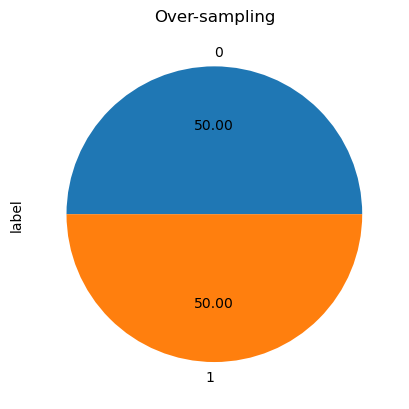

In [14]:
from imblearn.over_sampling import RandomOverSampler

ROS = RandomOverSampler(sampling_strategy=1)
X_ros, y_ros = ROS.fit_resample(X,y)

ax = y_ros.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title('Over-sampling')

In [15]:
df.drop(columns = ["text", "subcategory"])

,Unnamed: 0,title,label
0,0,FACEBOOK DELETES MICHIGAN ANTI-LOCKDOWN GROUP ...,0
1,1,Other Viewpoints: COVID-19 is worse than the flu,1
2,2,Bermuda's COVID-19 cases surpass 100,1
3,3,Purdue University says students face 'close to...,0
4,4,THE HIGH COST OF LOCKING DOWN AMERICA: WEVE ...,0
...,...,...,...
3114,2998,2019-nCoV: Health dept. on full alert,1
3115,2999,Screening machine for corona virus launched at...,1
3116,3000,Coronavirus (2019-nCoV),1
3117,3001,Characterizing Patients Hospitalized With COVI...,0


In [16]:
from sklearn.utils import shuffle

df = df.iloc[:, [1,-1]]  
df = df.sample(frac=1).reset_index(drop=True)  
display(df)

,title,label
0,"In UAE, If You Are Infected with Corona Virus,...",0
1,"corona virus, a medical take",1
2,Bespokes Morning Lineup  1/23/20  More Corona,1
3,Palace: 2019-nCoV under control,1
4,Supply chains and corona virus: danger from th...,1
...,...,...
3114,University officials monitoring 2019 Novel Cor...,1
3115,Child protection organizations seeing signifi...,0
3116,UN MOVES TO FIGHT INFODEMIC ON CORONA VIRUS,1
3117,Cepheid developing automated molecular test fo...,0


In [17]:
df['title'] = (df['title'].str.lower())
print(df)

                                                  title  label
0     in uae, if you are infected with corona virus,...      0
1                          corona virus, a medical take      1
2      bespokes morning lineup  1/23/20  more corona      1
3                       palace: 2019-ncov under control      1
4     supply chains and corona virus: danger from th...      1
...                                                 ...    ...
3114  university officials monitoring 2019 novel cor...      1
3115  child protection organizations seeing signifi...      0
3116        un moves to fight infodemic on corona virus      1
3117  cepheid developing automated molecular test fo...      0
3118  first case of corona virus in pakistan, 3 in f...      1

[3119 rows x 2 columns]


In [18]:
df['title'] = df['title'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
df.head()

,title,label
0,"in uae, if you are infected with corona virus,...",0
1,"corona virus, a medical take",1
2,bespokes morning lineup  1/23/20  more corona,1
3,palace: 2019-ncov under control,1
4,supply chains and corona virus: danger from th...,1


In [19]:
df['title'] = df['title'].str.replace(r"[\"\'\|\?\=\.\<\>\@\#\*\,]", '')
df.head()

,title,label
0,in uae if you are infected with corona virus y...,0
1,corona virus a medical take,1
2,bespokes morning lineup  1/23/20  more corona,1
3,palace: 2019-ncov under control,1
4,supply chains and corona virus: danger from th...,1


In [20]:
def tokenize(txt):
    if isinstance(txt, str):
        tokens = re.split('\W+', txt)
        return tokens
    else:
        return[]


In [21]:
df['title'] = df['title'].apply(lambda x: tokenize(str(x).lower()))
df.head()

,title,label
0,"[in, uae, if, you, are, infected, with, corona...",0
1,"[corona, virus, a, medical, take]",1
2,"[bespoke, s, morning, lineup, 1, 23, 20, more,...",1
3,"[palace, 2019, ncov, under, control]",1
4,"[supply, chains, and, corona, virus, danger, f...",1


In [22]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [23]:
def remove_punctuation(txt):
    txt_nopunct = " ".join([c for c in txt if c not in string.punctuation])
    return txt_nopunct

In [24]:
df['title'] = df['title'].apply(lambda x : remove_punctuation(x))
df.head()

,title,label
0,in uae if you are infected with corona virus y...,0
1,corona virus a medical take,1
2,bespoke s morning lineup 1 23 20 more corona,1
3,palace 2019 ncov under control,1
4,supply chains and corona virus danger from the...,1


In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
from nltk.corpus import stopwords

In [27]:
",".join(stopwords.words('english'))

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

In [28]:
stop_words = set(stopwords.words('english'))

In [29]:
def remove_stop(x):
    return ",".join([word for word in str(x).split() if word not in stop_words])

In [30]:
df['title'] = df['title'].apply(lambda x : remove_stop(x))
df.head()

,title,label
0,"uae,infected,corona,virus,bill,free",0
1,"corona,virus,medical,take",1
2,"bespoke,morning,lineup,1,23,20,corona",1
3,"palace,2019,ncov,control",1
4,"supply,chains,corona,virus,danger,far,east",1


In [31]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [32]:
lemmatizer = WordNetLemmatizer()

In [33]:
def data_processing(data):
    data = [lemmatizer.lemmatize(word) for word in data]
    data = ''.join(data)
    return data

In [34]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [35]:
df['title'] = df['title'].apply(lambda data: data_processing(data))
df.head()

,title,label
0,"uae,infected,corona,virus,bill,free",0
1,"corona,virus,medical,take",1
2,"bespoke,morning,lineup,1,23,20,corona",1
3,"palace,2019,ncov,control",1
4,"supply,chains,corona,virus,danger,far,east",1


In [36]:
train_df = df.sample(frac=0.8)
test_df = df.drop(train_df.index)

# reset index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('testset size:', test_df.shape)

trainset size: (2495, 2)
testset size: (624, 2)


In [37]:
print('Covid-19 length:', len(test_df))

print('Train real news:', train_df[train_df['label']==1].shape[0])
print('Train fake news:', train_df[train_df['label']==0].shape[0])

print('Test real news:', test_df[test_df['label']==1].shape[0])
print('Test fake news:', test_df[test_df['label']==0].shape[0])

Covid-19 length: 624
Train real news: 1647
Train fake news: 848
Test real news: 414
Test fake news: 210


In [38]:
X_train = train_df['title']
X_test = test_df['title']

y_train = train_df['label']
y_test = test_df['label']

print('Train data:', X_train.shape, y_train.shape)
print('Test data:', X_test.shape, y_test.shape)

Train data: (2495,) (2495,)
Test data: (624,) (624,)


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=10)

X_train_news_tfidf = vectorizer.fit_transform(X_train)
X_test_news_tfidf = vectorizer.transform(X_test)

print('X_train_news_tfidf shape:', X_train_news_tfidf.shape)
print('X_test_news_tfidf shape:', X_test_news_tfidf.shape)

X_train_news_tfidf shape: (2495, 260)
X_test_news_tfidf shape: (624, 260)


In [40]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = MultinomialNB()

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf,y_train)

best_params = grid_search.best_params_

final_clf = MultinomialNB(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('NB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

NB Classifier
Best hyperparameters: {'alpha': 1.0}
Accuracy:  0.7339743589743589
Precision:  0.7357414448669202
Recall:  0.9347826086956522
F1-score:  0.823404255319149


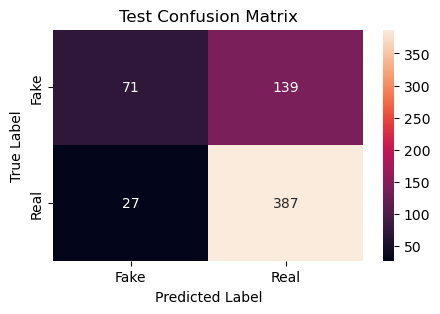

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = RandomForestClassifier()

param_grid = {'max_depth':[None,10,20], 'min_samples_leaf':[1,2,4], 'min_samples_split':[2,5,10], 'n_estimators':[10,50,100]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = RandomForestClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('RF Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

RF Classifier
Best hyperparameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy:  0.7564102564102564
Precision:  0.7416974169741697
Recall:  0.9710144927536232
F1-score:  0.8410041841004184


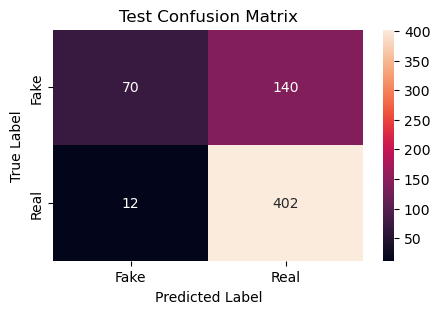

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = LogisticRegression()

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'penalty':['l1', 'l2']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = LogisticRegression(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('LR Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

LR Classifier
Best hyperparameters: {'C': 0.1, 'penalty': 'l2'}
Accuracy:  0.7307692307692307
Precision:  0.7135416666666666
Recall:  0.9927536231884058
F1-score:  0.8303030303030303


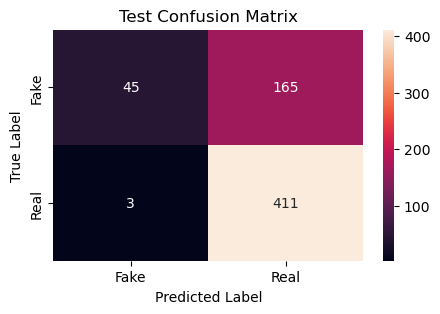

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [46]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = AdaBoostClassifier()

param_grid = {'n_estimators':[50,100,200], 'learning_rate':[0.01, 0.1, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = AdaBoostClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('AdaB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

AdaB Classifier
Best hyperparameters: {'learning_rate': 0.1, 'n_estimators': 50}
Accuracy:  0.7275641025641025
Precision:  0.7132867132867133
Recall:  0.9855072463768116
F1-score:  0.8275862068965518


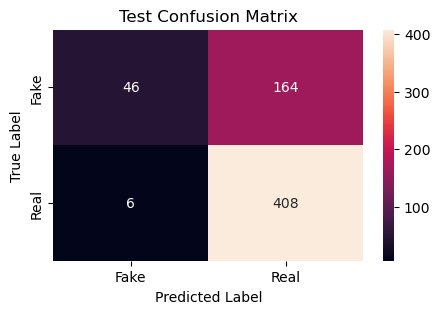

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = KNeighborsClassifier()

param_grid = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance'], 'p':[1,2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = KNeighborsClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('KNN Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

KNN Classifier
Best hyperparameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Accuracy:  0.7035256410256411
Precision:  0.8086253369272237
Recall:  0.7246376811594203
F1-score:  0.7643312101910827


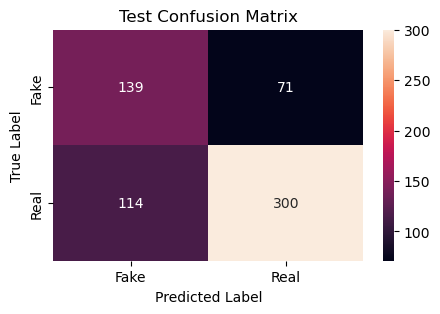

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [50]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = XGBClassifier()

param_grid = {'learning_rate':[0.01,0.1,0.2], 'n_estimators':[50,100,200], 'max_depth':[3,5,7], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0], 'gamma':[0,0.1,0.2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = XGBClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('XGB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

XGB Classifier
Best hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy:  0.7451923076923077
Precision:  0.7330895795246801
Recall:  0.9685990338164251
F1-score:  0.8345473465140478


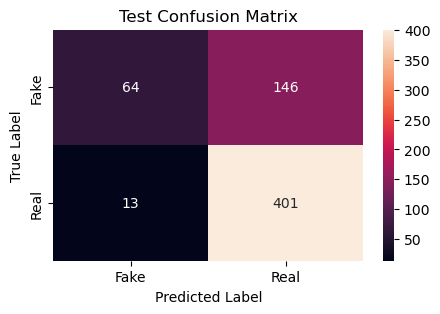

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = SVC()

param_grid = {'C':[0.1,1,10,100], 'kernel':['linear','rbf','poly','sigmoid']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = SVC(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('SVM Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

SVM Classifier
Best hyperparameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy:  0.7291666666666666
Precision:  0.7137870855148342
Recall:  0.9879227053140096
F1-score:  0.8287740628166159


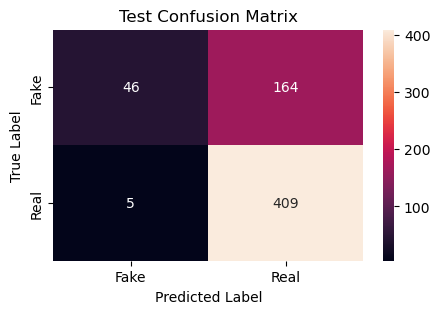

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [54]:
# DataFrame to csv

train_df.to_csv('train.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)